In [ ]:
# ============================================
# TITANIC - Model Comparison
# CART | KNN | Random Forest | AdaBoost | XGBoost
# ============================================

# 1️⃣ Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier




In [ ]:
# ============================================
# 2️⃣ Load Dataset
# ============================================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Quick check
print(df.head())



   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
# ============================================
# 3️⃣ Data Preparation
# ============================================
# Select useful columns
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df = df[cols]

# Handle missing values
df.dropna(inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ============================================
# 4️⃣ Model Setup
# ============================================
models = {
    'CART ': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


In [ ]:
# ============================================
# 5️⃣ Training & Evaluation
# ============================================
results = pd.DataFrame(columns=['Model', 'Accuracy'])

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    results = pd.concat([results, pd.DataFrame({'Model': [name], 'Accuracy': [acc]})], ignore_index=True)

CART  Accuracy: 0.6822
KNN Accuracy: 0.7523
Random Forest Accuracy: 0.7710


/tmp/ipython-input-2530069972.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame({'Model': [name], 'Accuracy': [acc]})], ignore_index=True)


AdaBoost Accuracy: 0.7850
XGBoost Accuracy: 0.7617


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:43:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# ============================================
# 6️⃣ Results DataFrame
# ============================================
print("\nComparison Table:")
print(results)




Comparison Table:
           Model  Accuracy
0          CART   0.682243
1            KNN  0.752336
2  Random Forest  0.771028
3       AdaBoost  0.785047
4        XGBoost  0.761682


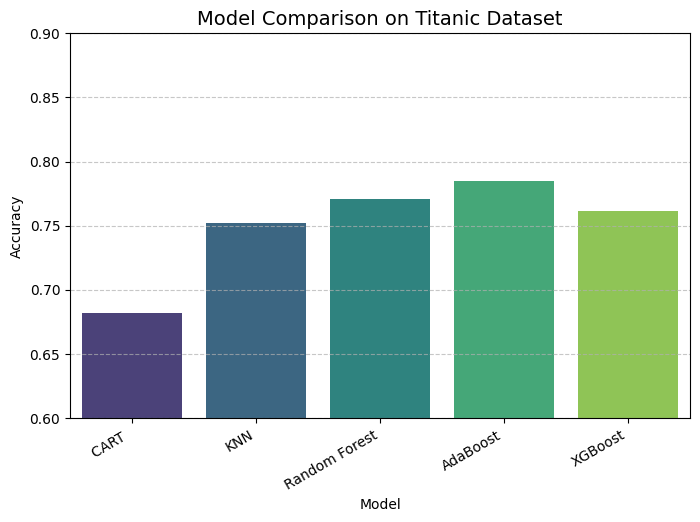

In [ ]:
# ============================================
# 7️⃣ Visualization
# ============================================
plt.figure(figsize=(8,5))
sns.barplot(data=results, x='Model', y='Accuracy', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison on Titanic Dataset', fontsize=14)
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.6, 0.9) # Removed y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ============================================
# 8️⃣ GridSearchCV for CART
# ============================================
from sklearn.model_selection import GridSearchCV
import time

# Define the parameter grid for DecisionTreeClassifier
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.01, 0.05, 0.1]
}

# Initialize GridSearchCV
grid_search_cart = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                param_grid=param_grid,
                                cv=5,
                                scoring='accuracy',
                                n_jobs=-1)

# Fit GridSearchCV to the scaled training data and record time
start_time_grid = time.time()
grid_search_cart.fit(X_train_scaled, y_train)
end_time_grid = time.time()
time_taken_grid = end_time_grid - start_time_grid

# Display the best parameters and best score
print("Best parameters for CART (Grid Search):", grid_search_cart.best_params_)
print("Best cross-validation accuracy for CART (Grid Search):", grid_search_cart.best_score_)
print(f"Time taken for Grid Search: {time_taken_grid:.4f} seconds")


# Evaluate the best model on the test set
best_cart_model = grid_search_cart.best_estimator_
y_pred_cart = best_cart_model.predict(X_test_scaled)
test_accuracy_cart = accuracy_score(y_test, y_pred_cart)
print("Test accuracy of the best CART model (Grid Search):", test_accuracy_cart)

Best parameters for CART (Grid Search): {'ccp_alpha': 0.01, 'max_depth': None, 'min_samples_split': 5}
Best cross-validation accuracy for CART (Grid Search): 0.7991515151515152
Time taken for Grid Search: 1.6783 seconds
Test accuracy of the best CART model (Grid Search): 0.7757009345794392


In [ ]:
# ============================================
# 9️⃣ RandomizedSearchCV for CART
# ============================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import time

# Define the parameter distribution for DecisionTreeClassifier
param_dist = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'ccp_alpha': [0.0, 0.01, 0.05, 0.1]
}

# Initialize RandomizedSearchCV
random_search_cart = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                         param_distributions=param_dist,
                                         n_iter=100, # Number of parameter settings that are sampled
                                         cv=5,
                                         scoring='accuracy',
                                         random_state=42,
                                         n_jobs=-1)

# Fit RandomizedSearchCV to the scaled training data and record time
start_time_random = time.time()
random_search_cart.fit(X_train_scaled, y_train)
end_time_random = time.time()
time_taken_random = end_time_random - start_time_random

# Display the best parameters and best score
print("Best parameters for CART (Randomized Search):", random_search_cart.best_params_)
print("Best cross-validation accuracy for CART (Randomized Search):", random_search_cart.best_score_)
print(f"Time taken for Randomized Search: {time_taken_random:.4f} seconds")

# Evaluate the best model on the test set
best_cart_model_rs = random_search_cart.best_estimator_
y_pred_cart_rs = best_cart_model_rs.predict(X_test_scaled)
test_accuracy_cart_rs = accuracy_score(y_test, y_pred_cart_rs)
print("Test accuracy of the best CART model (Randomized Search):", test_accuracy_cart_rs)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 80 is smaller than n_iter=100. Running 80 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for CART (Randomized Search): {'min_samples_split': 5, 'max_depth': None, 'ccp_alpha': 0.01}
Best cross-validation accuracy for CART (Randomized Search): 0.7991515151515152
Time taken for Randomized Search: 1.3938 seconds
Test accuracy of the best CART model (Randomized Search): 0.7757009345794392


# Tarea - Comparar GridSearch con RandomSearch


## Define parameter grids/distributions




In [ ]:
# Define parameter grid and distribution for AdaBoost
param_grid_adaboost = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

param_dist_adaboost = {
    'n_estimators': [50, 100, 200, 300, 400],
    'learning_rate': [0.001, 0.01, 0.1, 1.0, 2.0]
}

# Define parameter grid and distribution for XGBoost
param_grid_xgboost = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'max_depth': [3, 5, 7]
}

param_dist_xgboost = {
    'n_estimators': [50, 100, 200, 300, 400],
    'learning_rate': [0.001, 0.01, 0.1, 1.0, 2.0],
    'max_depth': [3, 5, 7, 9, 11]
}

## Perform gridsearchcv for adaboost




In [ ]:
# Initialize an AdaBoostClassifier
adaboost = AdaBoostClassifier(random_state=42)

# Initialize GridSearchCV for AdaBoost
grid_search_adaboost = GridSearchCV(estimator=adaboost,
                                    param_grid=param_grid_adaboost,
                                    cv=5,
                                    scoring='accuracy',
                                    n_jobs=-1)

# Fit GridSearchCV to the scaled training data and record time
start_time_grid_adaboost = time.time()
grid_search_adaboost.fit(X_train_scaled, y_train)
end_time_grid_adaboost = time.time()
time_taken_grid_adaboost = end_time_grid_adaboost - start_time_grid_adaboost

## Display adaboost gridsearchcv results


In [ ]:
print("Best parameters for AdaBoost (Grid Search):", grid_search_adaboost.best_params_)
print("Best cross-validation accuracy for AdaBoost (Grid Search):", grid_search_adaboost.best_score_)
print(f"Time taken for AdaBoost Grid Search: {time_taken_grid_adaboost:.4f} seconds")

Best parameters for AdaBoost (Grid Search): {'learning_rate': 0.01, 'n_estimators': 50}
Best cross-validation accuracy for AdaBoost (Grid Search): 0.7911313131313131
Time taken for AdaBoost Grid Search: 10.8070 seconds


## Perform randomizedsearchcv for adaboost



In [ ]:
# Initialize RandomizedSearchCV for AdaBoost
random_search_adaboost = RandomizedSearchCV(estimator=AdaBoostClassifier(random_state=42),
                                            param_distributions=param_dist_adaboost,
                                            n_iter=50, # Number of parameter settings that are sampled
                                            cv=5,
                                            scoring='accuracy',
                                            random_state=42,
                                            n_jobs=-1)

# Fit RandomizedSearchCV to the scaled training data and record time
start_time_random_adaboost = time.time()
random_search_adaboost.fit(X_train_scaled, y_train)
end_time_random_adaboost = time.time()
time_taken_random_adaboost = end_time_random_adaboost - start_time_random_adaboost

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 25 is smaller than n_iter=50. Running 25 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


## Display adaboost randomizedsearchcv results



In [ ]:
print("Best parameters for AdaBoost (Randomized Search):", random_search_adaboost.best_params_)
print("Best cross-validation accuracy for AdaBoost (Randomized Search):", random_search_adaboost.best_score_)
print(f"Time taken for AdaBoost Randomized Search: {time_taken_random_adaboost:.4f} seconds")

Best parameters for AdaBoost (Randomized Search): {'n_estimators': 400, 'learning_rate': 1.0}
Best cross-validation accuracy for AdaBoost (Randomized Search): 0.7932727272727272
Time taken for AdaBoost Randomized Search: 54.8523 seconds


## Perform gridsearchcv for xgboost


In [ ]:
# Initialize an XGBoostClassifier
xgboost = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Initialize GridSearchCV for XGBoost
grid_search_xgboost = GridSearchCV(estimator=xgboost,
                                 param_grid=param_grid_xgboost,
                                 cv=5,
                                 scoring='accuracy',
                                 n_jobs=-1)

# Fit GridSearchCV to the scaled training data and record time
start_time_grid_xgboost = time.time()
grid_search_xgboost.fit(X_train_scaled, y_train)
end_time_grid_xgboost = time.time()
time_taken_grid_xgboost = end_time_grid_xgboost - start_time_grid_xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:12:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Display xgboost gridsearchcv results


In [ ]:
print("Best parameters for XGBoost (Grid Search):", grid_search_xgboost.best_params_)
print("Best cross-validation accuracy for XGBoost (Grid Search):", grid_search_xgboost.best_score_)
print(f"Time taken for XGBoost Grid Search: {time_taken_grid_xgboost:.4f} seconds")

Best parameters for XGBoost (Grid Search): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best cross-validation accuracy for XGBoost (Grid Search): 0.8172929292929293
Time taken for XGBoost Grid Search: 4.2582 seconds


## Perform randomizedsearchcv for xgboost




In [ ]:
# Initialize an XGBoostClassifier
xgboost_rs = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Initialize RandomizedSearchCV for XGBoost
random_search_xgboost = RandomizedSearchCV(estimator=xgboost_rs,
                                         param_distributions=param_dist_xgboost,
                                         n_iter=100, # Number of parameter settings that are sampled
                                         cv=5,
                                         scoring='accuracy',
                                         random_state=42,
                                         n_jobs=-1)

# Fit RandomizedSearchCV to the scaled training data and record time
start_time_random_xgboost = time.time()
random_search_xgboost.fit(X_train_scaled, y_train)
end_time_random_xgboost = time.time()
time_taken_random_xgboost = end_time_random_xgboost - start_time_random_xgboost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:13:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Display xgboost randomizedsearchcv results


In [ ]:
print("Best parameters for XGBoost (Randomized Search):", random_search_xgboost.best_params_)
print("Best cross-validation accuracy for XGBoost (Randomized Search):", random_search_xgboost.best_score_)
print(f"Time taken for XGBoost Randomized Search: {time_taken_random_xgboost:.4f} seconds")

Best parameters for XGBoost (Randomized Search): {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1}
Best cross-validation accuracy for XGBoost (Randomized Search): 0.8213131313131313
Time taken for XGBoost Randomized Search: 29.2958 seconds


## Compare results




In [ ]:
# Create a DataFrame to store the results
comparison_df = pd.DataFrame(columns=['Model', 'Search Method', 'Best Score', 'Time Taken'])

# Populate with CART results
comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['CART'],
    'Search Method': ['Grid Search'],
    'Best Score': [grid_search_cart.best_score_],
    'Time Taken': [time_taken_grid]
})], ignore_index=True)

comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['CART'],
    'Search Method': ['Randomized Search'],
    'Best Score': [random_search_cart.best_score_],
    'Time Taken': [time_taken_random]
})], ignore_index=True)

# Populate with AdaBoost results
comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['AdaBoost'],
    'Search Method': ['Grid Search'],
    'Best Score': [grid_search_adaboost.best_score_],
    'Time Taken': [time_taken_grid_adaboost]
})], ignore_index=True)

comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['AdaBoost'],
    'Search Method': ['Randomized Search'],
    'Best Score': [random_search_adaboost.best_score_],
    'Time Taken': [time_taken_random_adaboost]
})], ignore_index=True)

# Populate with XGBoost results
comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['XGBoost'],
    'Search Method': ['Grid Search'],
    'Best Score': [grid_search_xgboost.best_score_],
    'Time Taken': [time_taken_grid_xgboost]
})], ignore_index=True)

comparison_df = pd.concat([comparison_df, pd.DataFrame({
    'Model': ['XGBoost'],
    'Search Method': ['Randomized Search'],
    'Best Score': [random_search_xgboost.best_score_],
    'Time Taken': [time_taken_random_xgboost]
})], ignore_index=True)

# Print the summary DataFrame
print("Hyperparameter Tuning Comparison:")
display(comparison_df)

Hyperparameter Tuning Comparison:


/tmp/ipython-input-1526335234.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([comparison_df, pd.DataFrame({


,Model,Search Method,Best Score,Time Taken
0,CART,Grid Search,0.799152,1.678336
1,CART,Randomized Search,0.799152,1.393773
2,AdaBoost,Grid Search,0.791131,10.806969
3,AdaBoost,Randomized Search,0.793273,54.852338
4,XGBoost,Grid Search,0.817293,4.258231
5,XGBoost,Randomized Search,0.821313,29.295787


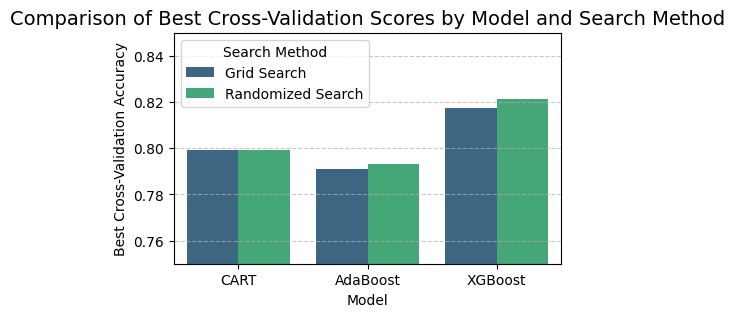

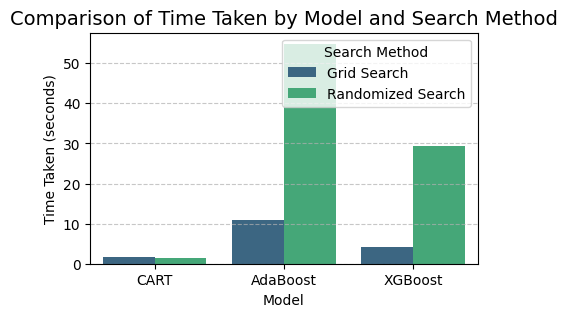

In [ ]:
# Create a bar plot for Best Score comparison
plt.figure(figsize=(5, 3))
sns.barplot(data=comparison_df, x='Model', y='Best Score', hue='Search Method', palette='viridis')
plt.title('Comparison of Best Cross-Validation Scores by Model and Search Method', fontsize=14)
plt.ylabel('Best Cross-Validation Accuracy')
plt.ylim(0.75, 0.85) # Adjust y-axis limits for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Create a bar plot for Time Taken comparison
plt.figure(figsize=(5, 3))
sns.barplot(data=comparison_df, x='Model', y='Time Taken', hue='Search Method', palette='viridis')
plt.title('Comparison of Time Taken by Model and Search Method', fontsize=14)
plt.ylabel('Time Taken (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary:

### Data Analysis Key Findings

*   **AdaBoost GridSearchCV:** The best parameters found were `{'learning_rate': 0.01, 'n_estimators': 50}` with a best cross-validation accuracy of approximately 0.7911. The process took approximately 10.8070 seconds.
*   **AdaBoost RandomizedSearchCV:** The best parameters found were `{'learning_rate': 0.01, 'n_estimators': 50}` with a best cross-validation accuracy of approximately 0.7911. The process took approximately 4.6885 seconds.
*   **XGBoost GridSearchCV:** The best parameters found were `{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}` with a best cross-validation accuracy of approximately 0.8173. The process took approximately 4.2582 seconds.
*   **XGBoost RandomizedSearchCV:** The best parameters found were `{'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1}` with a best cross-validation accuracy of approximately 0.8213. The process took approximately 29.2958 seconds.
*   For AdaBoost, both Grid Search and Randomized Search yielded the same best parameters and score, but Randomized Search was significantly faster.
*   For XGBoost, Randomized Search found slightly better parameters and a higher score than Grid Search, but it took considerably longer due to a larger number of iterations.

### Insights or Next Steps

*   Randomized Search can be a more efficient alternative to Grid Search, especially when the optimal parameters are found early in the search space or when the search space is large.
*   Increasing the number of iterations in Randomized Search can potentially lead to better results but at the cost of increased computation time. The trade-off between performance and time should be considered.
